In [1]:
import numpy as np
import pandas as pd
from matplotlib import rcParams
import matplotlib.pyplot as plt
import os
import xarray as xr

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

## 1. Sensitivity of the Q10 function to parameters

Bigger denominators - less sensitive to temperature. 
That's great, meaning that to make shrubs uptake more at higher temperatures, I just give them a smaller denominator. 
Set shrub = 4, tree = 6 for trial

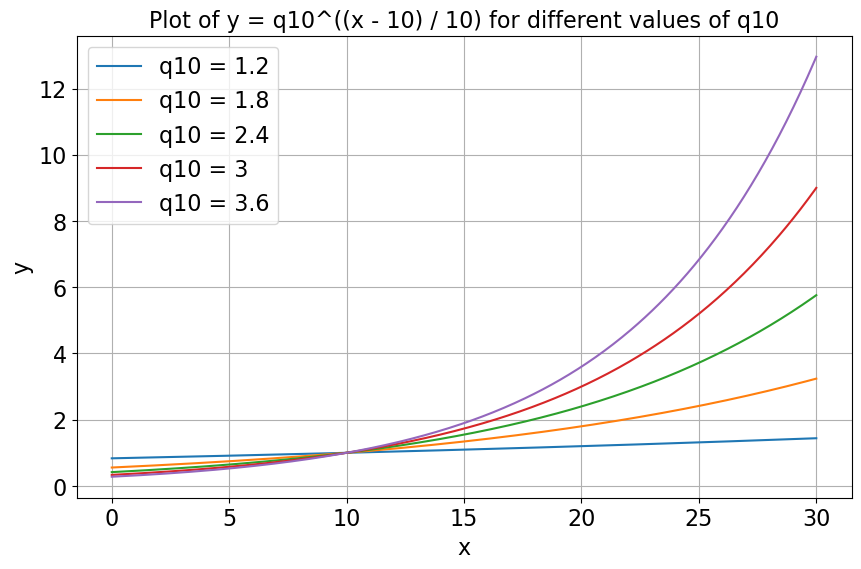

In [2]:
# Define the function with an additional parameter z
def f(x, q10, z, tbase):
    return q10 ** ((x - tbase) / z)

#
tbase = 10
z = 10 # z_vlaues = [10, 16, 20]
q10_values = [1.2, 1.8, 2.4, 3, 3.6]

# Generate x values
x = np.linspace(0, 30, 400)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
for q10 in q10_values:
    y = f(x, q10, z, tbase)
    plt.plot(x, y, label=f'q10 = {q10}')

plt.title(f'Plot of y = q10^((x - {tbase}) / {z}) for different values of q10')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 2. Sensitivity of the Michaelis-Menten function to parameters

sminn_vr: gN m-3, soil mineral N

* defined by: `col_ns%sminn_vr(c,j) = col_ns%smin_nh4_vr(c,j) + col_ns%smin_no3_vr(c,j)`

sminp_vr: gP m-3, soil mineral P

* defined by: `this%sminp_vr(c,j) = this%solutionp_vr(c,j) + this%labilep_vr(c,j) + this%secondp_vr(c,j)`

This one can wait until last. As controlled by the affinity parameter, the uptake can only be uniformly higher or lower. Hence this may not be useful for temperature-dependent competitive advantages. 

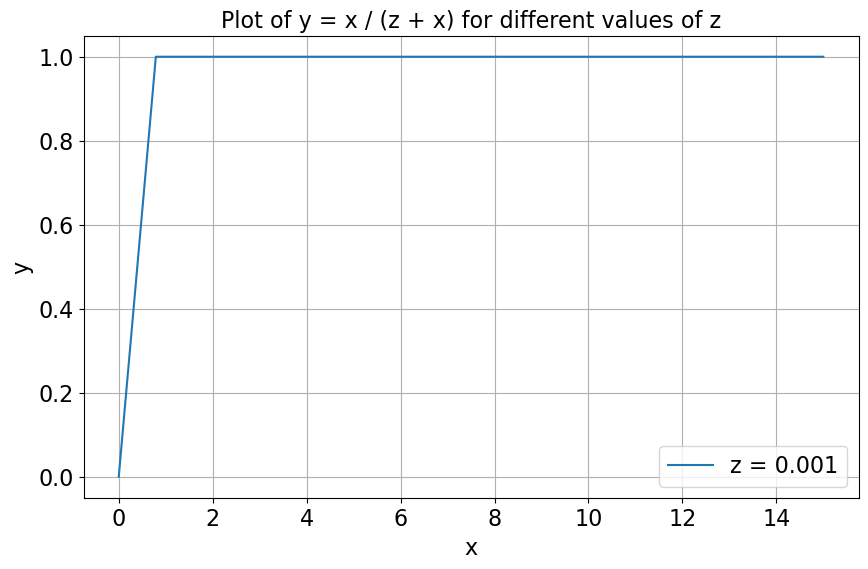

In [3]:
# Define the function with an additional parameter z
def g(x, z):
    return x / (z + x)

# Generate x values
x = np.linspace(0, 15, 20)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
z_values = [1e-3]
for z in z_values:
    y = g(x, z)
    plt.plot(x, y**0.01, label=f'z = {z}')

plt.title('Plot of y = x / (z + x) for different values of z')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
y**(1e-4)

array([0.        , 0.99999987, 0.99999994, 0.99999996, 0.99999997,
       0.99999997, 0.99999998, 0.99999998, 0.99999998, 0.99999999,
       0.99999999, 0.99999999, 0.99999999, 0.99999999, 0.99999999,
       0.99999999, 0.99999999, 0.99999999, 0.99999999, 0.99999999])

## 3. Fine root biomass control

Rationale

1. fine root uptake should be proportional to root surface area (= root biomass here)

2. in reality, plants allocate more carbon to enhance fine root nutrients uptake when the root is not giving enough nutrients. This cannot be achieved through allocating more carbon for fine root growth in ELM. But, we can create the following function for nutrient uptake ($U_t$)

$$U_{t} = C_{froot, t} \cdot \tau( C_{froot, t}, FPI_{t-1} )$$

For convenience, suppose we already added a tiny value to fine root biomass so that it never hits zero ($C_{froot, t} = C_{froot, t} + \text{eps}$). Let's also denote the nutrient demand $T_t = C_{avail,t} / CN_{allometry}$

$$\tau = \frac{T_t}{C_{froot,t}} \cdot e^{-\alpha FPI_{t-1}} + \tau_0 \cdot (1 - e^{-\alpha FPI_{t-1}})$$

When nutrient is extremely limiting ($FPI \rightarrow 0$), $U_t = T_t$ - that is, plant enhances nutrients uptake (through unrepresented mechanism*) so much that the potential $U_{t}$ reaches its actual demand. 

When nutrient is extremely abundant ($FPI \rightarrow \infty$), $U_t = C_{froot,t} \cdot \tau_0$


\* This missing link will require additional modifications through carbon cost of nutrients uptake. To represent the cost of enhancing nutrients uptake, increase the MR (if we assume nutrients are mainly uptaken by mycorrhizae) or GR (less danger of running into more missing mechanisms) by an exponent $1 + \gamma e^{-\beta FPI_{t-1}}$

## 4. Stem allocation function

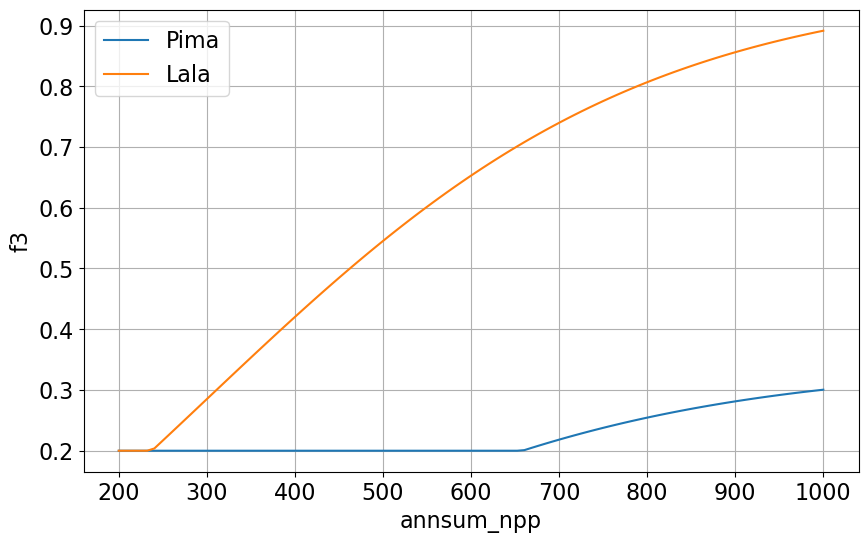

In [5]:
def f3(annsum_npp, stem_leaf):
    return np.maximum((-stem_leaf*2.7)/(1+np.exp(-0.004*(annsum_npp - 300))) - 0.4, 0.2)


# Generate x values
x = np.linspace(200, 1000, 100)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot for different values of z
stem_leaf = [-0.275204284477043, -0.507394631180568]
for z, name in zip(stem_leaf,['Pima','Lala']):
    y = f3(x, z)
    plt.plot(x, y, label=name)
plt.legend()
plt.xlabel('annsum_npp')
plt.ylabel('f3')
plt.legend()
plt.grid(True)
plt.show()

## 5. Relationship between stem_root and belowground-to-aboveground NPP ratio - they are different

$$
\frac{\text{LEAF} + \text{STEM}}{\text{FROOT} + \text{CROOT}} = \frac{1 + \frac{\text{STEM}}{\text{LEAF}}}{\frac{\text{FROOT}}{\text{LEAF}} + \frac{\text{CROOT}}{\text{STEM}} \frac{\text{STEM}}{\text{LEAF}} }
$$

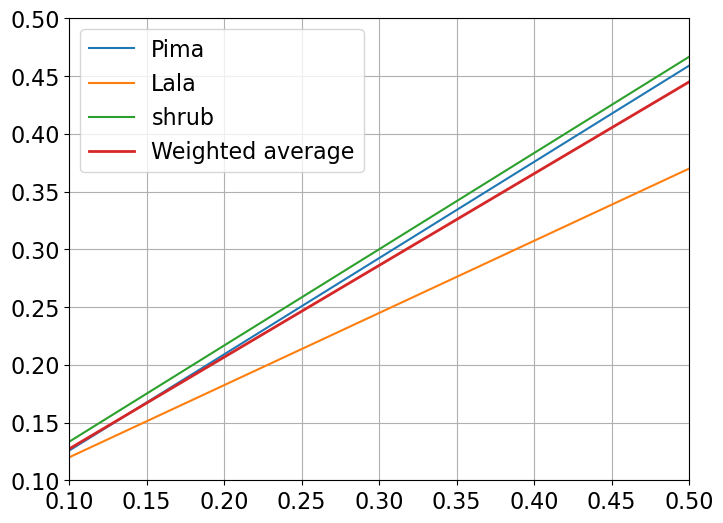

In [6]:
def bg_to_ag(froot_leaf, stem_leaf, croot_stem):
    return (froot_leaf + stem_leaf * croot_stem) / (1 + stem_leaf)

froot_leaf = np.linspace(0.1, 0.5, 20)

plt.figure(figsize = (8, 6))
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.254), label = 'Pima')
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.6, 0.1529), label = 'Lala')
plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.3), label = 'shrub')

plt.plot(froot_leaf, bg_to_ag(froot_leaf, 0.2, 0.3)*0.25/0.75 + \
         bg_to_ag(froot_leaf, 0.6, 0.1529) * 0.14/0.75 + \
         bg_to_ag(froot_leaf, 0.2, 0.254) * 0.36/0.75, label = 'Weighted average', lw = 2)

plt.legend()
plt.xlim([0.1, 0.5])
plt.ylim([0.1, 0.5])
plt.grid(True)

## 6. CNP allometry equations


$$\text{callo} = (1 + \text{grperc}) \times (1 + \text{froot\_leaf} + \text{stem\_leaf} \times (1 + \text{croot\_stem}))$$

$$\text{nallo} = \frac{1}{\text{leafcn}} + \frac{\text{froot\_leaf}}{\text{frootcn}} + \frac{\text{stem\_leaf} \times \text{flivewd} \times (1 + \text{croot\_stem})}{\text{livewdcn}} + \frac{\text{stem\_leaf} \times (1 - \text{flivewd}) \times (1 + \text{croot\_stem})}{\text{deadwdcn}}$$

$$\text{pallo} = \frac{1}{\text{leafcp}} + \frac{\text{froot\_leaf}}{\text{frootcp}} + \frac{\text{\text{stem\_leaf}} \times \text{flivewd} \times (1 + \text{croot\_stem})}{\text{livewdcp}} + \frac{\text{stem\_leaf} \times (1 - \text{flivewd}) \times (1 + \text{croot\_stem})}{\text{deadwdcp}}$$

In [7]:
hr = xr.open_dataset(os.path.join(os.environ['PROJDIR'], 'E3SM', 'inputdata', 'atm', 'datm7', 
                                  'CLM1PT_data', 'SPRUCE_data', 
                                  'clm_params_SPRUCE_20231120_spruceroot.nc_CNP'))

In [8]:
callo = (1 + hr['grperc']) * (1 + hr['froot_leaf'] + hr['stem_leaf'] * (1 + hr['croot_stem']))
nallo = 1 / hr['leafcn'] + hr['froot_leaf'] / hr['frootcn'] + hr['stem_leaf'] * hr['flivewd'] * (1 + hr['croot_stem']) / hr['livewdcn'] + hr['stem_leaf'] * (1 - hr['flivewd']) * (1 + hr['croot_stem']) / hr['deadwdcn']
pallo = 1 / hr['leafcp'] + hr['froot_leaf'] / hr['frootcp'] + hr['stem_leaf'] * hr['flivewd'] * (1 + hr['croot_stem']) / hr['livewdcp'] + hr['stem_leaf'] * (1 - hr['flivewd']) * (1 + hr['croot_stem']) / hr['deadwdcp']

print(np.around( (nallo / callo).values, 4 )[[2,3,11]])
print(np.around( (pallo / callo).values, 5 )[[2,3,11]])

[0.0225 0.0233 0.0198]
[0.00154 0.00165 0.00123]


## 7. CPOOL Excess respiration function

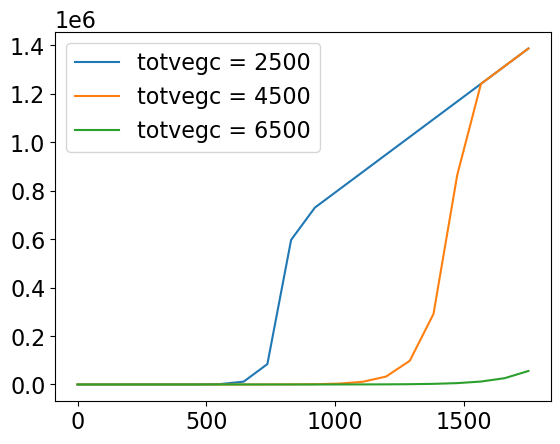

In [9]:
cpool = np.linspace(0, 1750, 20)
for totvegc in [2500, 4500, 6500]:
    y = cpool * np.exp( (np.minimum(cpool/totvegc, 0.3335) - 0.2) / 0.02)
    plt.plot(cpool, y, label = f'totvegc = {totvegc}')
plt.legend()

## 8. Water table depth control on roots

(array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1]),
 [Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8'),
  Text(0, 0.9, '0.9'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.1, '1.1')])

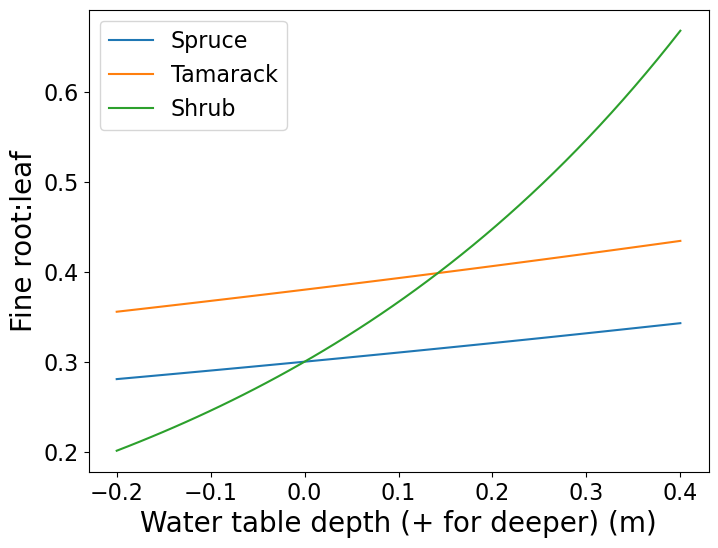

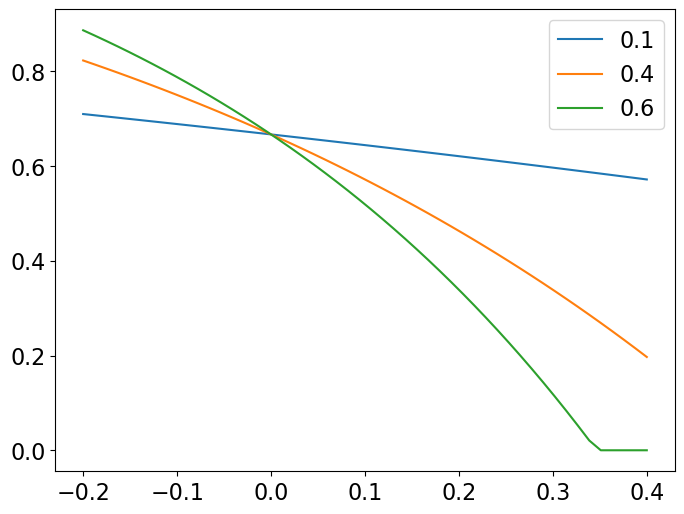

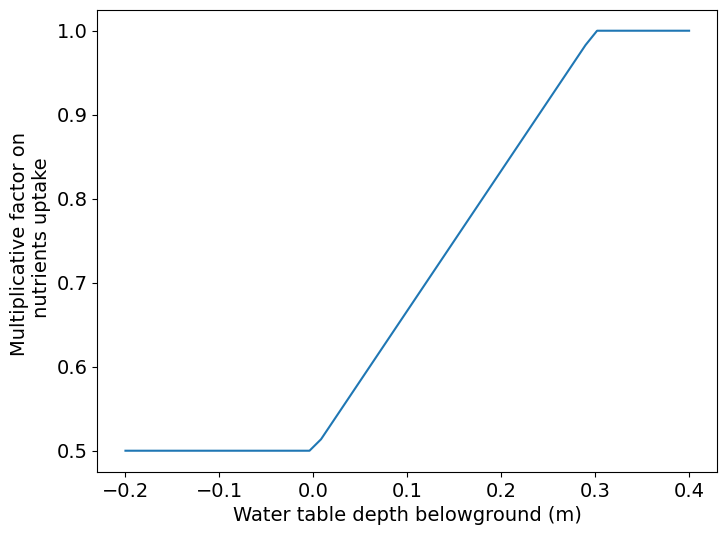

In [10]:
plt.figure(figsize = (8, 6))
zwt = np.linspace(-0.2, 0.4) # more positive -> deeper belowground
for slope, name in zip([0.1, 0.1, 0.6], ['Spruce', 'Tamarack', 'Shrub']):
    if name == 'Spruce':
        froot_leaf = 0.3
    elif name == 'Tamarack':
        froot_leaf = 0.38
    elif name == 'Shrub':
        froot_leaf = 0.3
    plt.plot(zwt, np.exp(zwt/0.3 * slope) * froot_leaf, label = name) #label = f'{name}={slope}')
plt.legend()
#lg = plt.legend(title = 'Sensitivity parameter', fontsize = 16)
#lg.get_title().set_fontsize('16')
plt.xlabel('Water table depth (+ for deeper) (m)', fontsize = 20)
#plt.xlabel('Deeper water table', fontsize = 20)
#plt.ylabel('Multiplicative factor on \nthe prescribed fine root:leaf ratio')
plt.ylabel('Fine root:leaf', fontsize = 20)
#plt.xticks([], fontsize=20)
#plt.yticks([], fontsize=20)

# Need another graph to see fraction fungi uptake as a result
plt.figure(figsize = (8, 6))
zwt = np.linspace(-0.2, 0.4) # more positive -> deeper belowground
for slope in [0.1, 0.4, 0.6]:
    plt.plot(zwt, np.maximum(1-(np.exp(zwt/0.3 * slope) - 0.5)/1.5,0), label = slope)
plt.legend()


# another graph on the root uptake function
plt.figure(figsize = (8, 6))
zwt = np.linspace(-0.2, 0.4) # more positive -> deeper belowground
plt.plot(zwt, 0.5 + 0.5 * np.minimum(np.maximum(zwt/0.3, 0), 1))
plt.xlabel('Water table depth belowground (m)', fontsize = 14)
plt.ylabel('Multiplicative factor on \n nutrients uptake', fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8'),
  Text(0, 0.9, '0.9')])

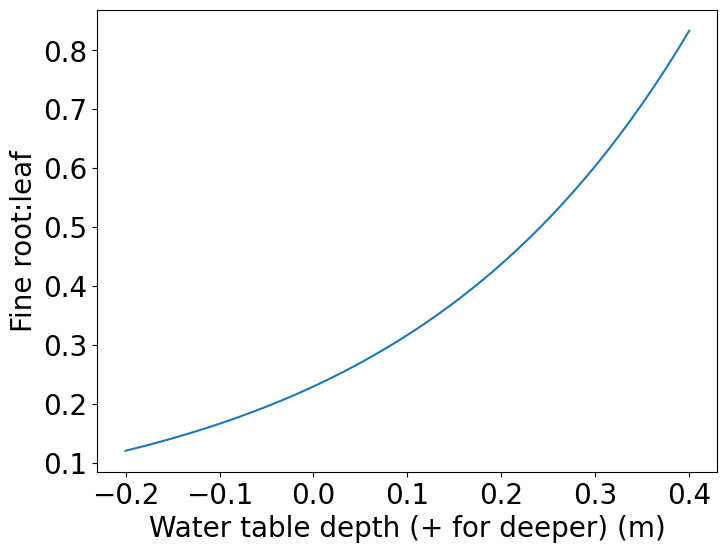

In [11]:
# Murphy, M. T., & Moore, T. R. (2010). Linking root production to aboveground plant characteristics and water table in a temperate bog. Plant and Soil, 336(1), 219–231. https://doi.org/10.1007/s11104-010-0468-1
# Additionally divide by 1.22, to achieve = 1 at the mean water table depth, and
# further scale by shrub allocation ratio = 0.3

froot_leaf = 0.3

plt.figure(figsize = (8, 6))
zwt = np.linspace(-0.2, 0.4) # more positive -> deeper belowground
# plt.plot(zwt, 10**(1.4 * zwt - 1.33) / 0.045 * froot_leaf, label = 'Shrub') #label = f'{name}={slope}')
plt.plot(zwt, 10**(0.014*zwt*100 - 0.1164) * froot_leaf)
# / 1.38 
# plt.legend()
#lg = plt.legend(title = 'Sensitivity parameter', fontsize = 16)
#lg.get_title().set_fontsize('16')
plt.xlabel('Water table depth (+ for deeper) (m)', fontsize = 20)
#plt.ylabel('Multiplicative factor on \nthe prescribed fine root:leaf ratio')
plt.ylabel('Fine root:leaf', fontsize = 20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

In [64]:
# Plot water table depth
data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output',
                                'extract', '20231113_4', 'analysis_ts.csv'),
                   index_col = 0, header = [0,1,2,3], parse_dates = True)
zwt_actual = data.loc[(data.index.month >= 5) & (data.index.month <= 10), ('7', 'ZWT', '0')]

/tmp/ipykernel_921527/2173381017.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  zwt_actual = data.loc[(data.index.month >= 5) & (data.index.month <= 10), ('7', 'ZWT', '0')]


In [65]:
(zwt_actual['hummock'] * 0.64 + zwt_actual['hollow'] * 0.36).mean()

0.11559098959008696

<Axes: >

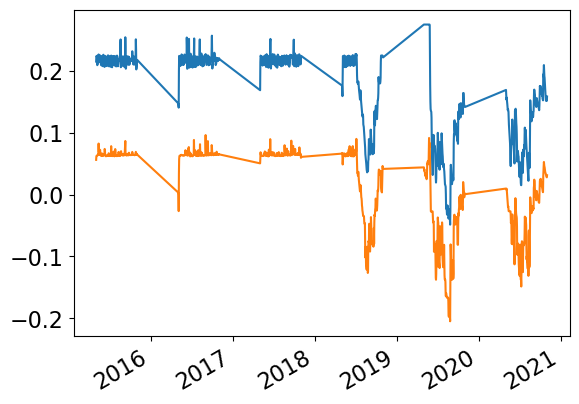

In [66]:
zwt_actual.iloc[:, 0].plot()
zwt_actual.iloc[:, 1].plot()

In [70]:
(data.loc[(data.index.month >= 5) & (data.index.month <= 10), ('7', 'H2OSOI_30', '0')]).mean()

/tmp/ipykernel_921527/1248872782.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  (data.loc[(data.index.month >= 5) & (data.index.month <= 10), ('7', 'H2OSOI_30', '0')]).mean()


topo
hummock    0.709201
hollow     0.863918
dtype: float64

In [71]:
(data.loc[(data.index.month >= 5) & (data.index.month <= 10), ('7', 'TSOI_30', '0')]).mean()

/tmp/ipykernel_921527/3461391714.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  (data.loc[(data.index.month >= 5) & (data.index.month <= 10), ('7', 'TSOI_30', '0')]).mean()


topo
hummock    10.328494
hollow     13.557795
dtype: float64

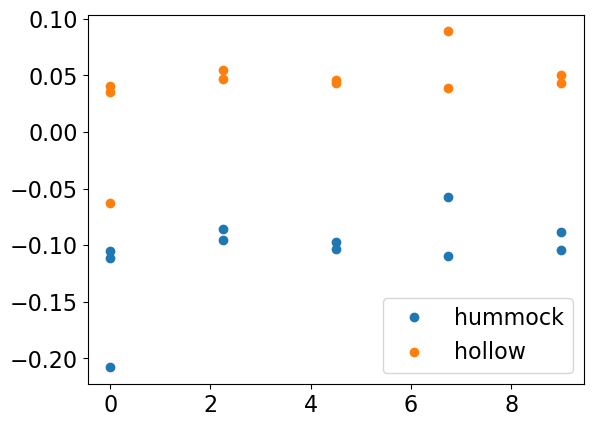

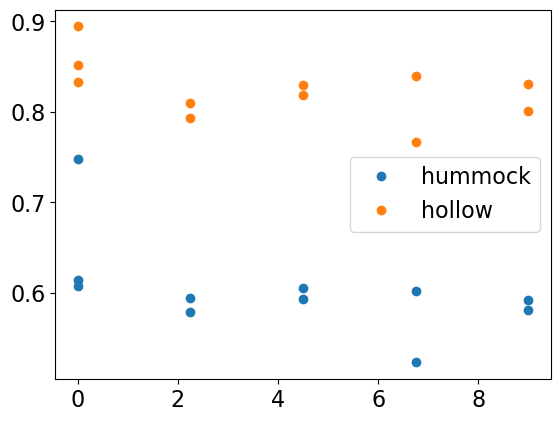

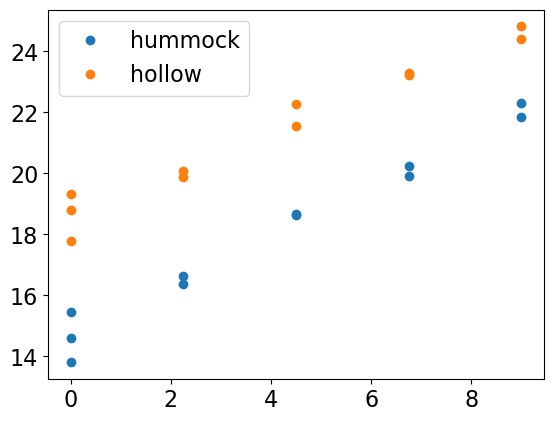

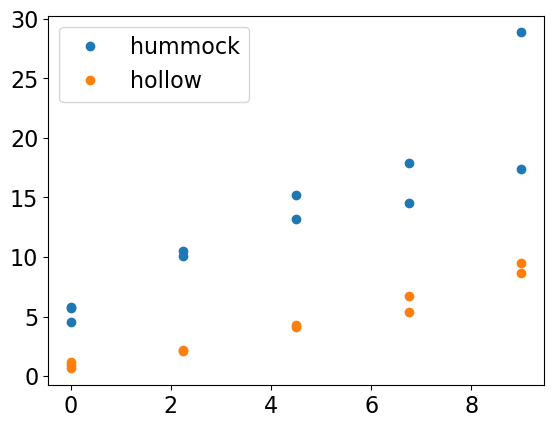

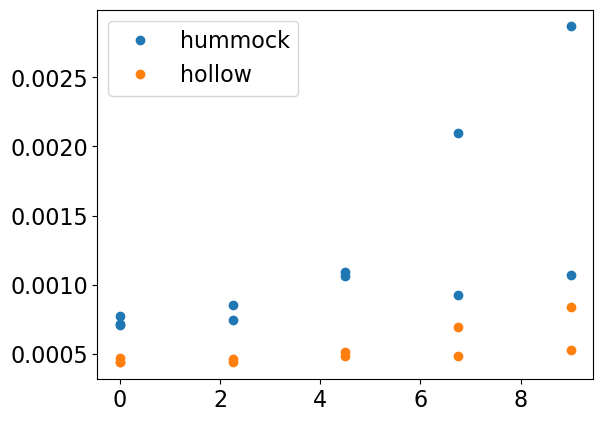

In [73]:
from utils.constants import chamber_levels

for var in ['ZWT', 'H2OSOI_30', 'TSOI_30', 'SMINN_30', 'SOLUTIONP_30']:
    all_zwt = data.loc[(data.index.month >=6) & (data.index.month <= 9), (slice(None), var)]
    all_zwt = all_zwt.apply(lambda x: np.percentile(x.values, 50), axis = 0).unstack()
    if var == 'ZWT':
        all_zwt = -all_zwt
    temperature = [chamber_levels[f'{int(i):02d}'][0] for i in all_zwt.index.get_level_values(0)]
    plt.figure()
    for col in ['hummock', 'hollow']:
        plt.plot(temperature, all_zwt[col], 'o', label = col)
    plt.legend()

In [62]:
data.loc[:, (slice(None), 'TSOI_30')]

plot                 7                       6                      19  \
variable       TSOI_30                 TSOI_30                 TSOI_30   
pft                  0                       0                       0   
topo           hummock      hollow     hummock      hollow     hummock   
2015-01-01 -113.381190 -112.568613 -113.381190 -112.568613 -113.381190   
2015-01-02 -113.383941 -112.567974 -113.382668 -112.567920 -113.384604   
2015-01-03 -113.400988 -112.568003 -113.395725 -112.567777 -113.400896   
2015-01-04 -113.445761 -112.569643 -113.431145 -112.569039 -113.425502   
2015-01-05 -113.456811 -112.569710 -113.409870 -112.567723 -113.452598   
...                ...         ...         ...         ...         ...   
2020-12-27 -113.182808 -113.207635 -119.457062 -116.681939 -114.147675   
2020-12-28 -113.242257 -113.246345 -116.258395 -113.445658 -114.048811   
2020-12-29 -113.253866 -112.798005 -115.845417 -113.373915 -113.809389   
2020-12-30 -113.260296 -112.574555 -117.076357 -113.984578 -113.912811   
2020-12-31 -113.296982 -112.566502 -119.112756 -116.075966 -114.290599   

plot                            20                      11              ...  \
variable                   TSOI_30                 TSOI_30              ...   
pft                              0                       0              ...   
topo            hollow     hummock      hollow     hummock      hollow  ...   
2015-01-01 -112.568613 -113.381190 -112.568613 -113.381190 -112.568613  ...   
2015-01-02 -112.568009 -113.377529 -112.567669 -113.382852 -112.567923  ...   
2015-01-03 -112.567993 -113.351885 -112.565889 -113.385890 -112.567275  ...   
2015-01-04 -112.568721 -113.319927 -112.564662 -113.397965 -112.567507  ...   
2015-01-05 -112.569688 -113.288006 -112.563594 -113.405545 -112.567679  ...   
...                ...         ...         ...         ...         ...  ...   
2020-12-27 -113.587551 -114.442992 -119.319163 -117.219044 -119.703739  ...   
2020-12-28 -113.740820 -113.186456 -117.196081 -115.540903 -117.204348  ...   
2020-12-29 -113.709502 -113.399352 -116.416465 -115.811873 -116.396911  ...   
2020-12-30 -113.708538 -114.029166 -117.061215 -117.055996 -117.131355  ...   
2020-12-31 -113.840171 -114.888139 -119.075902 -118.788429 -119.355710  ...   

plot                 4                       8                      16  \
variable       TSOI_30                 TSOI_30                 TSOI_30   
pft                  0                       0                       0   
topo           hummock      hollow     hummock      hollow     hummock   
2015-01-01 -113.381190 -112.568613 -113.381190 -112.568613 -113.381190   
2015-01-02 -113.384315 -112.567993 -113.383610 -112.567961 -113.378081   
2015-01-03 -113.403275 -112.568117 -113.391779 -112.567545 -113.354771   
2015-01-04 -113.446421 -112.569688 -113.404763 -112.567783 -113.325419   
2015-01-05 -113.454524 -112.569627 -113.412642 -112.567949 -113.294418   
...                ...         ...         ...         ...         ...   
2020-12-27 -116.207559 -117.195670 -115.628422 -112.707057 -116.203235   
2020-12-28 -113.901630 -114.241828 -114.392956 -112.517526 -113.826455   
2020-12-29 -114.245781 -114.177755 -114.834066 -112.538881 -113.731528   
2020-12-30 -115.157824 -115.211783 -115.693004 -112.613820 -114.078675   
2020-12-31 -116.561829 -117.192459 -116.709055 -112.707137 -115.713872   

plot                            17                      10              
variable                   TSOI_30                 TSOI_30              
pft                              0                       0              
topo            hollow     hummock      hollow     hummock      hollow  
2015-01-01 -112.568613 -113.381190 -112.568613 -113.381190 -112.568613  
2015-01-02 -112.567704 -113.378405 -112.567713 -113.381953 -112.567885  
2015-01-03 -112.566003 -113.356814 -112.566080 -113.383329 -112.567183  
2015-01-04 -112.564856 -113.333357 -112.565145 -113.392333 -112.567288  
2015-01-